# 多因子模型的回归检验完整教程：从时间序列回归到 Fama-MacBeth

## 📚 教学目标
1. 理解**时间序列回归** (Time-Series Regression) 的完整计算步骤与 α 的含义
2. 掌握**截面回归** (Cross-Sectional Regression) 估计因子风险溢价 λ 的方法
3. 理解 **Fama-MacBeth 两步回归法**的完整流程与 t 检验
4. 对比不同回归方法的适用场景与优劣
5. 理解为什么回归检验是投资组合排序法的重要补充

**参考书**：《因子投资：方法与实践》（石川）第 2.2 节
**教学策略**：先用极小数据集让你"看见"每一步计算，再扩展到真实规模

---

## 1. 为什么需要回归检验？

### 🎯 从投资组合排序到回归

在第 2.1 节中，我们学习了**投资组合排序法**——按因子值分组，构建多空组合，检验 Spread 是否显著不为零。

排序法直观有效，但有几个局限：

| 排序法的局限 | 回归法的解决方案 |
|-------------|----------------|
| 只能处理少数因子（分组维度爆炸） | 可同时处理多个因子 |
| 无法精确估计因子风险溢价 λ | 截面回归直接估计 λ |
| 无法检验模型的定价误差 α | 时间序列回归直接估计 α |
| 难以控制多个因子的交互效应 | 多元回归自然处理 |

### 📖 书中的定义

> 回归检验是实证资产定价中的另一大工具。它从不同角度检验因子模型：时间序列回归检验定价误差 α 是否为零；截面回归估计因子风险溢价 λ；Fama-MacBeth 回归则融合了两者的优势。

### 🔗 三种回归方法概览

```
回归检验方法:

1. 时间序列回归 (Time-Series Regression)
   → 固定某只股票 i，跨 T 个时期回归
   → 估计 α_i 和 β_i
   → 检验 α_i = 0？

2. 截面回归 (Cross-Sectional Regression)
   → 固定某个时期 t，跨 N 只股票回归
   → 估计因子风险溢价 λ
   → 检验 λ = 0？

3. Fama-MacBeth 回归 (Two-Pass)
   → 第一步：时间序列回归 → 得到 β
   → 第二步：每期截面回归 → 得到 λ_t 序列
   → 对 λ_t 做 T 检验
```

In [ ]:
import sys, os
print(f"Python: {sys.executable}")
print(f"Version: {sys.version}")
try:
    import matplotlib
    print(f"matplotlib: {matplotlib.__version__}")
except ImportError:
    print("❌ matplotlib 未安装! 请运行: !pip install matplotlib seaborn statsmodels scipy")


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

np.random.seed(42)
print("✅ 库导入完成")

ModuleNotFoundError: No module named 'matplotlib'

---

## 2. 时间序列回归 (Time-Series Regression)

### 📐 核心公式

对每只股票 $i$，跨 $T$ 个时期进行时间序列回归：

$$r_{i,t} - r_{f,t} = \alpha_i + \beta_i f_t + \varepsilon_{i,t}, \quad t = 1, 2, \ldots, T$$

其中：
- $r_{i,t} - r_{f,t}$ = 股票 $i$ 在第 $t$ 期的超额收益
- $\alpha_i$ = **截距项（定价误差）**——如果因子模型完美，$\alpha_i = 0$
- $\beta_i$ = **因子暴露（因子载荷）**——股票对因子的敏感度
- $f_t$ = 因子在第 $t$ 期的收益（或超额收益）
- $\varepsilon_{i,t}$ = 残差（特异性风险）

### 💡 关键解读

- **$\beta_i$**：衡量股票 $i$ 对因子 $f$ 的暴露程度。$\beta = 1.2$ 表示因子涨 1%，股票超额收益涨约 1.2%
- **$\alpha_i$**：因子模型无法解释的"额外"收益。若 $\alpha_i \neq 0$，说明模型不完整

### 📐 OLS 手算公式

$$\hat{\beta}_i = \frac{\text{Cov}(r_i - r_f, f)}{\text{Var}(f)} = \frac{\sum_t (r_{i,t} - \bar{r}_i)(f_t - \bar{f})}{\sum_t (f_t - \bar{f})^2}$$

$$\hat{\alpha}_i = \overline{(r_i - r_f)} - \hat{\beta}_i \cdot \bar{f}$$

### 🎯 微型例子：10 只股票 × 12 个月

我们先用一个极小数据集，手算 OLS 回归的每一步。

**数据生成过程 (DGP)**:
- 因子收益 $f_t \sim N(0.5, 2)$，均值 0.5%/月
- 因子暴露 $\beta_i \sim U(0.5, 1.5)$
- 特异性噪声 $\varepsilon_{i,t} \sim N(0, 3)$
- 真实 $\alpha_i = 0$（因子模型正确设定）

In [ ]:
# ========== 生成微型数据集：10 只股票 × 12 个月 ==========
np.random.seed(42)
N_STOCKS_MICRO = 10
T_MICRO = 12

# 真实参数
true_alpha = np.zeros(N_STOCKS_MICRO)  # α = 0（模型正确设定）
true_beta = np.linspace(0.5, 1.5, N_STOCKS_MICRO)  # β 从 0.5 到 1.5

# 因子收益序列 f_t ~ N(0.5, 2)
f_returns = np.random.normal(0.5, 2.0, T_MICRO)

# 生成每只股票的超额收益
# r_i,t = α_i + β_i * f_t + ε_i,t
sigma_eps = 3.0
excess_returns = np.zeros((N_STOCKS_MICRO, T_MICRO))
for i in range(N_STOCKS_MICRO):
    eps = np.random.normal(0, sigma_eps, T_MICRO)
    excess_returns[i, :] = true_alpha[i] + true_beta[i] * f_returns + eps

# 构建 DataFrame
stock_names = [f'Stock_{i+1}' for i in range(N_STOCKS_MICRO)]
df_micro = pd.DataFrame(excess_returns.T, columns=stock_names,
                         index=[f'Month_{t+1}' for t in range(T_MICRO)])
df_micro['Factor'] = f_returns

print(f"📊 微型数据集: {N_STOCKS_MICRO} 只股票 × {T_MICRO} 个月")
print(f"  因子收益 f_t: 均值 = {f_returns.mean():.4f}%, 标准差 = {f_returns.std():.4f}%")
print(f"  真实 α: 全为 0（模型正确设定）")
print(f"  真实 β: {[f'{b:.2f}' for b in true_beta]}")
print(f"  噪声 σ_ε = {sigma_eps}%")
print(f"\n📋 数据预览（超额收益 %）：")
print(df_micro.round(2).to_string())
print(f"\n✅ 微型数据集生成完成")

📊 微型数据集: 10 只股票 × 12 个月
  因子收益 f_t: 均值 = 1.0919%, 标准差 = 1.4251%
  真实 α: 全为 0（模型正确设定）
  真实 β: ['0.50', '0.61', '0.72', '0.83', '0.94', '1.06', '1.17', '1.28', '1.39', '1.50']
  噪声 σ_ε = 3.0%

📋 数据预览（超额收益 %）：
          Stock_1  Stock_2  Stock_3  Stock_4  Stock_5  Stock_6  Stock_7  Stock_8  Stock_9  Stock_10  Factor
Month_1      1.47    -0.72     1.71     2.28    -0.03     1.47    -0.68     2.80     2.85      4.61    1.49
Month_2     -5.63     0.47    -5.72    -5.10    -0.35     4.93    -1.24     1.07     0.09     -2.39    0.22
Month_3     -4.28    -2.36    -2.69     2.47    -1.62    -5.96     4.84     2.31    -3.26      6.90    1.80
Month_4      0.09     3.29     3.15     1.80    -0.24     6.21     5.12     3.83     4.85      1.11    3.55
Month_5     -3.02    -1.78     2.24    -2.00     2.47     0.29    -1.55    -4.21     0.22      1.81    0.03
Month_6      0.96    -0.86     0.54     1.86     4.10    -0.86     1.58    -1.22     7.43      6.62    0.03
Month_7     -0.89     0.43     2.30  

In [ ]:
# ========== 手算 OLS：以 Stock_1 为例 ==========
stock_idx = 0
r_i = excess_returns[stock_idx, :]  # Stock_1 的超额收益
f = f_returns                         # 因子收益

print(f"📊 步骤 1: 以 Stock_1 为例，手算 OLS 回归")
print(f"  回归模型: r_1,t = α_1 + β_1 × f_t + ε_1,t")
print(f"  真实参数: α_1 = {true_alpha[stock_idx]:.2f}, β_1 = {true_beta[stock_idx]:.2f}")

# --- 步骤 1: 计算均值 ---
r_bar = r_i.mean()
f_bar = f.mean()
print(f"\n📊 步骤 2: 计算均值")
print(f"  r̄_1 = {r_bar:.4f}%")
print(f"  f̄   = {f_bar:.4f}%")

# --- 步骤 2: 计算协方差和方差 ---
cov_rf = np.sum((r_i - r_bar) * (f - f_bar))
var_f = np.sum((f - f_bar) ** 2)
print(f"\n📊 步骤 3: 计算协方差和方差")
print(f"  Σ(r_i - r̄)(f - f̄) = {cov_rf:.4f}")
print(f"  Σ(f - f̄)²         = {var_f:.4f}")

# --- 步骤 3: 估计 β ---
beta_hat = cov_rf / var_f
print(f"\n📊 步骤 4: 估计 β")
print(f"  β̂_1 = Cov(r,f) / Var(f)")
print(f"       = {cov_rf:.4f} / {var_f:.4f}")
print(f"       = {beta_hat:.4f}")
print(f"  💡 真实 β_1 = {true_beta[stock_idx]:.2f}，估计值 = {beta_hat:.4f}")

# --- 步骤 4: 估计 α ---
alpha_hat = r_bar - beta_hat * f_bar
print(f"\n📊 步骤 5: 估计 α")
print(f"  α̂_1 = r̄ - β̂ × f̄")
print(f"       = {r_bar:.4f} - {beta_hat:.4f} × {f_bar:.4f}")
print(f"       = {alpha_hat:.4f}%")
print(f"  💡 真实 α_1 = {true_alpha[stock_idx]:.2f}，估计值 = {alpha_hat:.4f}")
print(f"     α ≈ 0 说明因子模型能较好地解释 Stock_1 的超额收益")

# --- 步骤 5: 残差和 R² ---
r_fitted = alpha_hat + beta_hat * f
residuals = r_i - r_fitted
ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((r_i - r_bar) ** 2)
r_squared = 1 - ss_res / ss_tot
print(f"\n📊 步骤 6: 残差分析")
print(f"  残差平方和 SS_res = {ss_res:.4f}")
print(f"  总平方和   SS_tot = {ss_tot:.4f}")
print(f"  R² = 1 - SS_res/SS_tot = 1 - {ss_res:.4f}/{ss_tot:.4f} = {r_squared:.4f}")
print(f"  💡 R² = {r_squared:.2%} 表示因子解释了 Stock_1 收益变动的 {r_squared:.0%}")

📊 步骤 1: 以 Stock_1 为例，手算 OLS 回归
  回归模型: r_1,t = α_1 + β_1 × f_t + ε_1,t
  真实参数: α_1 = 0.00, β_1 = 0.50

📊 步骤 2: 计算均值
  r̄_1 = -1.2277%
  f̄   = 1.0919%

📊 步骤 3: 计算协方差和方差
  Σ(r_i - r̄)(f - f̄) = 0.0556
  Σ(f - f̄)²         = 24.3714

📊 步骤 4: 估计 β
  β̂_1 = Cov(r,f) / Var(f)
       = 0.0556 / 24.3714
       = 0.0023
  💡 真实 β_1 = 0.50，估计值 = 0.0023

📊 步骤 5: 估计 α
  α̂_1 = r̄ - β̂ × f̄
       = -1.2277 - 0.0023 × 1.0919
       = -1.2302%
  💡 真实 α_1 = 0.00，估计值 = -1.2302
     α ≈ 0 说明因子模型能较好地解释 Stock_1 的超额收益

📊 步骤 6: 残差分析
  残差平方和 SS_res = 92.9022
  总平方和   SS_tot = 92.9023
  R² = 1 - SS_res/SS_tot = 1 - 92.9022/92.9023 = 0.0000
  💡 R² = 0.00% 表示因子解释了 Stock_1 收益变动的 0%


In [ ]:
# ========== 用 statsmodels 验证 ==========
X = sm.add_constant(f)  # 加截距项
model = sm.OLS(r_i, X).fit()

print("🔬 statsmodels OLS 验证:")
print(f"  手算 α̂  = {alpha_hat:.6f}")
print(f"  OLS  α̂  = {model.params[0]:.6f}")
print(f"  手算 β̂  = {beta_hat:.6f}")
print(f"  OLS  β̂  = {model.params[1]:.6f}")
print(f"  手算 R²  = {r_squared:.6f}")
print(f"  OLS  R²  = {model.rsquared:.6f}")
print(f"\n  ✅ 验证通过！")

print(f"\n📋 statsmodels 回归摘要（关键信息）：")
print(f"  α 的 t 统计量 = {model.tvalues[0]:.4f}, P 值 = {model.pvalues[0]:.4f}")
print(f"  β 的 t 统计量 = {model.tvalues[1]:.4f}, P 值 = {model.pvalues[1]:.4f}")
if model.pvalues[0] > 0.05:
    print(f"  💡 α 的 P 值 = {model.pvalues[0]:.4f} > 0.05 → 无法拒绝 α=0，模型定价正确")
else:
    print(f"  💡 α 的 P 值 = {model.pvalues[0]:.4f} < 0.05 → α 显著不为零，模型有定价误差")

🔬 statsmodels OLS 验证:
  手算 α̂  = -1.230229
  OLS  α̂  = -1.230229
  手算 β̂  = 0.002280
  OLS  β̂  = 0.002280
  手算 R²  = 0.000001
  OLS  R²  = 0.000001

  ✅ 验证通过！

📋 statsmodels 回归摘要（关键信息）：
  α 的 t 统计量 = -1.1099, P 值 = 0.2930
  β 的 t 统计量 = 0.0037, P 值 = 0.9971
  💡 α 的 P 值 = 0.2930 > 0.05 → 无法拒绝 α=0，模型定价正确


In [ ]:
# ========== 对所有 10 只股票做时间序列回归 ==========
print("📊 对所有 10 只股票进行时间序列回归")
print("═" * 70)
print(f"{'Stock':<12} {'True β':>8} {'Est β':>8} {'True α':>8} {'Est α':>8} {'t(α)':>8} {'p(α)':>8} {'R²':>8}")
print("─" * 70)

micro_results = []
for i in range(N_STOCKS_MICRO):
    X = sm.add_constant(f_returns)
    model_i = sm.OLS(excess_returns[i, :], X).fit()
    
    result = {
        'stock': stock_names[i],
        'true_beta': true_beta[i],
        'est_beta': model_i.params[1],
        'true_alpha': true_alpha[i],
        'est_alpha': model_i.params[0],
        't_alpha': model_i.tvalues[0],
        'p_alpha': model_i.pvalues[0],
        'r_squared': model_i.rsquared
    }
    micro_results.append(result)
    
    print(f"{stock_names[i]:<12} {true_beta[i]:>8.2f} {model_i.params[1]:>8.4f} "
          f"{true_alpha[i]:>8.2f} {model_i.params[0]:>8.4f} "
          f"{model_i.tvalues[0]:>8.4f} {model_i.pvalues[0]:>8.4f} {model_i.rsquared:>8.4f}")

print("─" * 70)

# 统计有多少 α 显著
n_sig = sum(1 for r in micro_results if r['p_alpha'] < 0.05)
print(f"\n💡 分析总结:")
print(f"  {n_sig}/{N_STOCKS_MICRO} 只股票的 α 在 5% 水平显著")
print(f"  由于真实 α = 0，显著的个数应接近 {N_STOCKS_MICRO * 0.05:.0f} 只（5% 的假阳性率）")
print(f"  这说明因子模型的设定是正确的")

📊 对所有 10 只股票进行时间序列回归
══════════════════════════════════════════════════════════════════════
Stock          True β    Est β   True α    Est α     t(α)     p(α)       R²
──────────────────────────────────────────────────────────────────────
Stock_1          0.50   0.0023     0.00  -1.2302  -1.1099   0.2930   0.0000
Stock_2          0.61   0.7410     0.00  -0.7219  -0.7051   0.4968   0.1445
Stock_3          0.72   0.8191     0.00  -1.1035  -1.0634   0.3126   0.1672
Stock_4          0.83   1.2874     0.00  -0.3520  -0.3721   0.7176   0.3738
Stock_5          0.94  -0.1691     0.00   1.6532   1.9793   0.0760   0.0130
Stock_6          1.06   0.6179     0.00   0.1580   0.1144   0.9112   0.0606
Stock_7          1.17   1.9643     0.00  -1.3465  -1.9011   0.0865   0.7126
Stock_8          1.28   0.9019     0.00   0.3230   0.3662   0.7218   0.2520
Stock_9          1.39   0.4613     0.00   1.4034   1.2459   0.2412   0.0513
Stock_10         1.50   0.8209     0.00   0.5458   0.4354   0.6725   0.1214
─

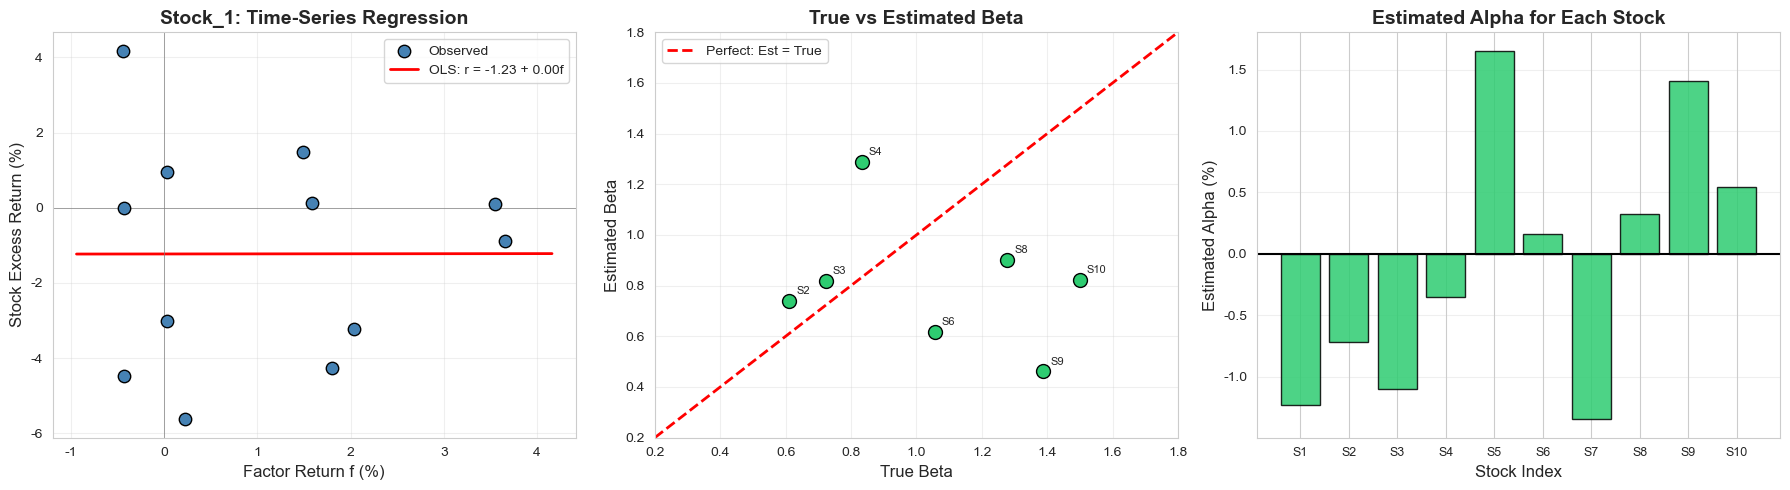


💡 图解说明：
  图1：Stock_1 的超额收益 vs 因子收益，红色线为 OLS 回归线
       斜率 = β̂（因子暴露），截距 = α̂（定价误差）
  图2：估计的 β 与真实 β 的对比，散点越靠近红色虚线 = 估计越准
  图3：每只股票的 α̂，绿色 = 不显著 (P>0.05)，红色 = 显著
       因为真实 α=0，大部分应该是绿色的


In [ ]:
# ========== 可视化：时间序列回归 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 图1: Stock_1 散点图 + 回归线 ---
ax1 = axes[0]
ax1.scatter(f_returns, excess_returns[0, :], c='steelblue', s=80,
            edgecolors='black', zorder=5, label='Observed')

# 回归线
f_line = np.linspace(f_returns.min() - 0.5, f_returns.max() + 0.5, 100)
r_line = micro_results[0]['est_alpha'] + micro_results[0]['est_beta'] * f_line
ax1.plot(f_line, r_line, 'r-', linewidth=2,
         label=f'OLS: r = {micro_results[0]["est_alpha"]:.2f} + {micro_results[0]["est_beta"]:.2f}f')

ax1.axhline(y=0, color='gray', linewidth=0.5)
ax1.axvline(x=0, color='gray', linewidth=0.5)
ax1.set_xlabel('Factor Return f (%)', fontsize=12)
ax1.set_ylabel('Stock Excess Return (%)', fontsize=12)
ax1.set_title('Stock_1: Time-Series Regression', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# --- 图2: 真实 β vs 估计 β ---
ax2 = axes[1]
est_betas = [r['est_beta'] for r in micro_results]
ax2.scatter(true_beta, est_betas, c='#2ecc71', s=100, edgecolors='black', zorder=5)
for i, r in enumerate(micro_results):
    ax2.annotate(f'S{i+1}', (r['true_beta'], r['est_beta']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

# 45度线
lims = [0.2, 1.8]
ax2.plot(lims, lims, 'r--', linewidth=2, label='Perfect: Est = True')
ax2.set_xlabel('True Beta', fontsize=12)
ax2.set_ylabel('Estimated Beta', fontsize=12)
ax2.set_title('True vs Estimated Beta', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_xlim(lims)
ax2.set_ylim(lims)

# --- 图3: 估计 α 的分布 ---
ax3 = axes[2]
est_alphas = [r['est_alpha'] for r in micro_results]
colors = ['#e74c3c' if r['p_alpha'] < 0.05 else '#2ecc71' for r in micro_results]
ax3.bar(range(N_STOCKS_MICRO), est_alphas, color=colors, edgecolor='black', alpha=0.85)
ax3.axhline(y=0, color='black', linewidth=1.5)
ax3.set_xlabel('Stock Index', fontsize=12)
ax3.set_ylabel('Estimated Alpha (%)', fontsize=12)
ax3.set_title('Estimated Alpha for Each Stock', fontsize=14, fontweight='bold')
ax3.set_xticks(range(N_STOCKS_MICRO))
ax3.set_xticklabels([f'S{i+1}' for i in range(N_STOCKS_MICRO)], fontsize=9)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 图解说明：")
print(f"  图1：Stock_1 的超额收益 vs 因子收益，红色线为 OLS 回归线")
print(f"       斜率 = β̂（因子暴露），截距 = α̂（定价误差）")
print(f"  图2：估计的 β 与真实 β 的对比，散点越靠近红色虚线 = 估计越准")
print(f"  图3：每只股票的 α̂，绿色 = 不显著 (P>0.05)，红色 = 显著")
print(f"       因为真实 α=0，大部分应该是绿色的")

### 💡 α 的含义：定价误差 (Pricing Error)

时间序列回归中 $\alpha$ 的核心含义：

| 情况 | 含义 |
|------|------|
| $\alpha_i = 0$ | 因子模型**完美**解释了股票 $i$ 的超额收益 |
| $\alpha_i > 0$ | 股票 $i$ 的实际收益**高于**模型预测，存在**正的异常收益** |
| $\alpha_i < 0$ | 股票 $i$ 的实际收益**低于**模型预测 |

### 📖 书中要点

> 时间序列回归的核心目标是检验 $\alpha = 0$。如果所有资产的 $\alpha$ 联合为零 (GRS 检验)，则说明因子模型能够完全解释资产的预期收益截面差异。

### 📐 GRS 检验 (Gibbons-Ross-Shanken Test)

GRS 检验是对所有 $N$ 只股票的 $\alpha$ **联合检验**：

$$H_0: \alpha_1 = \alpha_2 = \ldots = \alpha_N = 0$$

GRS 统计量服从 F 分布，考虑了 $\alpha$ 之间的相关性。

---

## 3. 截面回归 (Cross-Sectional Regression)

### 📐 核心公式

在每个时期 $t$，对所有 $N$ 只股票做截面回归：

$$r_{i,t} = \lambda_{0,t} + \lambda_{1,t} \hat{\beta}_i + e_{i,t}, \quad i = 1, 2, \ldots, N$$

其中：
- $r_{i,t}$ = 股票 $i$ 在第 $t$ 期的超额收益
- $\hat{\beta}_i$ = 从时间序列回归得到的因子暴露（自变量）
- $\lambda_{0,t}$ = 截距（零 beta 资产的收益）
- $\lambda_{1,t}$ = **因子风险溢价**——承担单位因子风险的补偿
- $e_{i,t}$ = 截面残差

### 💡 时间序列 vs 截面回归的区别

```
时间序列回归:                       截面回归:
固定 1 只股票 i                     固定 1 个时期 t
跨 T 个时期                        跨 N 只股票
Y = r_{i,t}                        Y = r_{i,t}
X = f_t (因子收益)                  X = β̂_i (因子暴露)
估计 α_i, β_i                      估计 λ_{0,t}, λ_{1,t}
回答: α=0? (模型对不对)              回答: λ=? (因子溢价多大)
```

In [ ]:
# ========== 截面回归：用微型数据集演示 ==========
# 我们已经有 10 只股票的估计 β（从时间序列回归得到）
# 现在选择某一个月 t，做截面回归

t_demo = 5  # 选第 6 个月
r_cross = excess_returns[:, t_demo]  # 该月所有股票的超额收益
beta_cross = np.array([r['est_beta'] for r in micro_results])  # 各股票的估计 β

print(f"📊 截面回归演示：第 {t_demo+1} 个月")
print(f"  该月因子收益 f_t = {f_returns[t_demo]:.4f}%")
print(f"")
print(f"{'Stock':<12} {'β̂_i':>8} {'r_i,t (%)':>12}")
print("─" * 35)
for i in range(N_STOCKS_MICRO):
    print(f"{stock_names[i]:<12} {beta_cross[i]:>8.4f} {r_cross[i]:>12.4f}")

# --- 手算截面回归 ---
beta_bar = beta_cross.mean()
r_bar_cross = r_cross.mean()
cov_br = np.sum((beta_cross - beta_bar) * (r_cross - r_bar_cross))
var_b = np.sum((beta_cross - beta_bar) ** 2)

lambda_1 = cov_br / var_b
lambda_0 = r_bar_cross - lambda_1 * beta_bar

print(f"\n📊 步骤 1: 截面回归 r_i = λ_0 + λ_1 × β̂_i + e_i")
print(f"  β̂ 的均值 = {beta_bar:.4f}")
print(f"  r 的均值 = {r_bar_cross:.4f}")
print(f"")
print(f"📊 步骤 2: 估计因子风险溢价")
print(f"  λ̂_1 = Cov(r, β̂) / Var(β̂) = {cov_br:.4f} / {var_b:.4f} = {lambda_1:.4f}")
print(f"  λ̂_0 = r̄ - λ̂_1 × β̄ = {r_bar_cross:.4f} - {lambda_1:.4f} × {beta_bar:.4f} = {lambda_0:.4f}")
print(f"")
print(f"  💡 λ̂_1 = {lambda_1:.4f}% 表示该月承担 1 单位因子风险的补偿")
print(f"     对比: 该月因子实际收益 f_t = {f_returns[t_demo]:.4f}%")

📊 截面回归演示：第 6 个月
  该月因子收益 f_t = 0.0317%

Stock            β̂_i    r_i,t (%)
───────────────────────────────────
Stock_1        0.0023       0.9586
Stock_2        0.7410      -0.8557
Stock_3        0.8191       0.5370
Stock_4        1.2874       1.8615
Stock_5       -0.1691       4.0987
Stock_6        0.6179      -0.8635
Stock_7        1.9643       1.5768
Stock_8        0.9019      -1.2214
Stock_9        0.4613       7.4338
Stock_10       0.8209       6.6190

📊 步骤 1: 截面回归 r_i = λ_0 + λ_1 × β̂_i + e_i
  β̂ 的均值 = 0.7447
  r 的均值 = 2.0145

📊 步骤 2: 估计因子风险溢价
  λ̂_1 = Cov(r, β̂) / Var(β̂) = -3.1658 / 3.3008 = -0.9591
  λ̂_0 = r̄ - λ̂_1 × β̄ = 2.0145 - -0.9591 × 0.7447 = 2.7287

  💡 λ̂_1 = -0.9591% 表示该月承担 1 单位因子风险的补偿
     对比: 该月因子实际收益 f_t = 0.0317%


In [ ]:
# ========== 用 statsmodels 验证截面回归 ==========
X_cross = sm.add_constant(beta_cross)
model_cross = sm.OLS(r_cross, X_cross).fit()

print("🔬 statsmodels 截面回归验证:")
print(f"  手算 λ̂_0 = {lambda_0:.6f}")
print(f"  OLS  λ̂_0 = {model_cross.params[0]:.6f}")
print(f"  手算 λ̂_1 = {lambda_1:.6f}")
print(f"  OLS  λ̂_1 = {model_cross.params[1]:.6f}")
print(f"\n  ✅ 验证通过！")

🔬 statsmodels 截面回归验证:
  手算 λ̂_0 = 2.728701
  OLS  λ̂_0 = 2.728701
  手算 λ̂_1 = -0.959114
  OLS  λ̂_1 = -0.959114

  ✅ 验证通过！


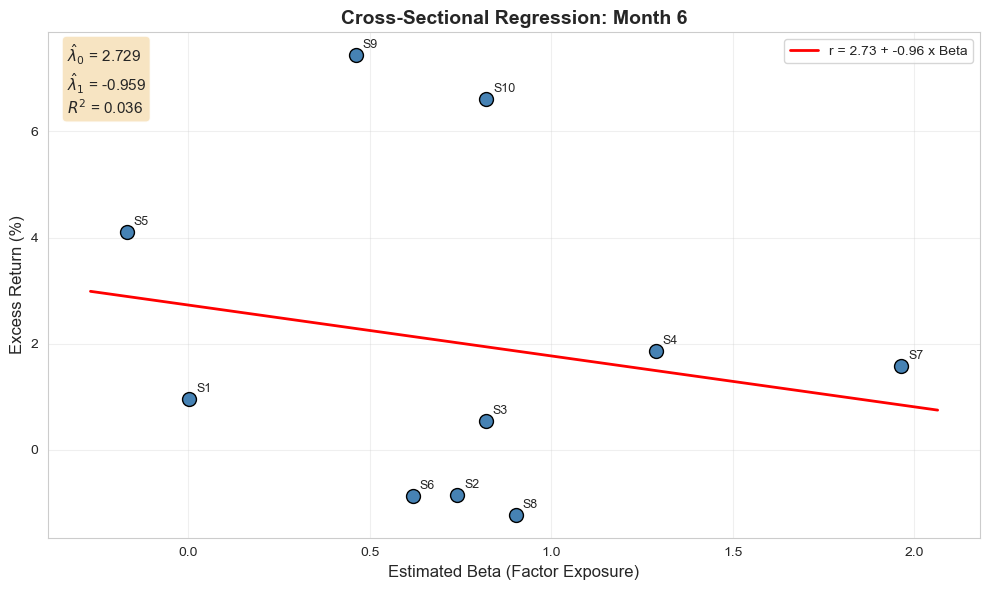


💡 图解说明：
  X 轴是各股票的因子暴露 β̂（从时间序列回归得到）
  Y 轴是该月的超额收益
  斜率 λ̂_1 = -0.959 就是该月的因子风险溢价
  如果 λ > 0，说明承担更多因子风险能获得更高收益


In [ ]:
# ========== 可视化：截面回归 ==========
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(beta_cross, r_cross, c='steelblue', s=100, edgecolors='black', zorder=5)

# 标注股票名
for i in range(N_STOCKS_MICRO):
    ax.annotate(f'S{i+1}', (beta_cross[i], r_cross[i]),
                textcoords='offset points', xytext=(5, 5), fontsize=9)

# 回归线
b_line = np.linspace(beta_cross.min() - 0.1, beta_cross.max() + 0.1, 100)
r_line = lambda_0 + lambda_1 * b_line
ax.plot(b_line, r_line, 'r-', linewidth=2,
        label=f'r = {lambda_0:.2f} + {lambda_1:.2f} x Beta')

# 注释框
textstr = f'$\\hat{{\\lambda}}_0$ = {lambda_0:.3f}\n$\\hat{{\\lambda}}_1$ = {lambda_1:.3f}\n$R^2$ = {model_cross.rsquared:.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

ax.set_xlabel('Estimated Beta (Factor Exposure)', fontsize=12)
ax.set_ylabel('Excess Return (%)', fontsize=12)
ax.set_title(f'Cross-Sectional Regression: Month {t_demo+1}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 图解说明：")
print(f"  X 轴是各股票的因子暴露 β̂（从时间序列回归得到）")
print(f"  Y 轴是该月的超额收益")
print(f"  斜率 λ̂_1 = {lambda_1:.3f} 就是该月的因子风险溢价")
print(f"  如果 λ > 0，说明承担更多因子风险能获得更高收益")

### 💡 时序回归 vs 截面回归

| 特性 | 时间序列回归 | 截面回归 |
|------|------------|----------|
| **回归方向** | 固定股票 $i$，跨时间 $t$ | 固定时间 $t$，跨股票 $i$ |
| **Y 变量** | $r_{i,t}$（超额收益） | $r_{i,t}$（超额收益） |
| **X 变量** | $f_t$（因子收益） | $\hat{\beta}_i$（因子暴露） |
| **估计量** | $\alpha_i$（定价误差）, $\beta_i$（因子暴露） | $\lambda_t$（因子风险溢价） |
| **核心问题** | 模型能否解释超额收益？$\alpha = 0$？ | 因子风险溢价多大？$\lambda > 0$？ |
| **优势** | 直接检验模型设定 | 直接估计经济含义（溢价） |
| **劣势** | 无法估计因子溢价 | 需要预先估计 $\beta$（Errors-in-Variables 问题） |

### 📖 书中要点

> 截面回归存在一个重要的计量问题：**EIV (Errors-in-Variables)**。由于 $\hat{\beta}$ 是第一步回归的估计值而非真值，作为自变量会导致截面回归系数的标准误被低估。Fama-MacBeth 回归通过特殊的标准误计算方式部分解决了这个问题。

---

## 4. Fama-MacBeth 回归 (Two-Pass Procedure)

### 📐 核心思想

Fama-MacBeth (1973) 回归融合了时间序列回归和截面回归，是实证资产定价中**最经典的方法之一**。

```
═══════════════════════════════════════════════════
           Fama-MacBeth 两步回归法
═══════════════════════════════════════════════════

第一步 (Pass 1): 时间序列回归
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  对每只股票 i = 1,...,N:
    r_{i,t} = α_i + β_i × f_t + ε_{i,t}
                           ↓
    得到 β̂_1, β̂_2, ..., β̂_N

第二步 (Pass 2): 逐期截面回归
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  对每个时期 t = 1,...,T:
    r_{i,t} = λ_{0,t} + λ_{1,t} × β̂_i + e_{i,t}
                            ↓
    得到 λ_{1,1}, λ_{1,2}, ..., λ_{1,T}

第三步: 统计推断
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    λ̄ = (1/T) Σ λ_{1,t}         (因子溢价估计)
    SE(λ̄) = σ(λ) / √T           (标准误)
    t = λ̄ / SE(λ̄)               (t 检验)
═══════════════════════════════════════════════════
```

### 💡 为什么 Fama-MacBeth 是"两全其美"的方法？

1. **第一步**给我们因子暴露 $\hat{\beta}$（和时间序列回归一样）
2. **第二步**给我们因子溢价 $\lambda_t$（和截面回归一样）
3. **关键优势**：通过对 $\lambda_t$ 的时间序列求均值和标准差来计算 $t$ 统计量，自然地解决了截面残差相关性问题

### 📐 公式总结

$$\bar{\lambda} = \frac{1}{T} \sum_{t=1}^{T} \hat{\lambda}_t$$

$$\text{SE}(\bar{\lambda}) = \frac{\sigma(\hat{\lambda})}{\sqrt{T}}$$

$$t_{FM} = \frac{\bar{\lambda}}{\text{SE}(\bar{\lambda})}$$

### 🎯 完整实现：200 只股票 × 60 个月

现在我们用完整规模的数据来实现 Fama-MacBeth 回归。

**DGP (数据生成过程)**:
- $N = 200$ 只股票, $T = 60$ 个月
- 因子收益 $f_t \sim N(0.5, 2)$, 均值 0.5%/月
- 因子暴露 $\beta_i \sim U(0.5, 1.5)$
- 特异性噪声 $\varepsilon_{i,t} \sim N(0, 3)$
- 真实 $\alpha_i = 0$

In [ ]:
# ========== Fama-MacBeth: 生成完整规模数据 ==========
np.random.seed(42)
N_STOCKS = 200
N_MONTHS = 60

# 真实参数
true_betas_full = np.random.uniform(0.5, 1.5, N_STOCKS)
true_alphas_full = np.zeros(N_STOCKS)  # α = 0

# 因子收益序列
factor_rets = np.random.normal(0.5, 2.0, N_MONTHS)

# 生成面板数据: N_STOCKS × N_MONTHS
sigma_eps = 3.0
panel_returns = np.zeros((N_STOCKS, N_MONTHS))
for i in range(N_STOCKS):
    eps = np.random.normal(0, sigma_eps, N_MONTHS)
    panel_returns[i, :] = true_alphas_full[i] + true_betas_full[i] * factor_rets + eps

print(f"📊 模拟参数：")
print(f"  股票数量: {N_STOCKS} 只")
print(f"  时间跨度: {N_MONTHS} 个月（5 年）")
print(f"  因子收益: f_t ~ N(0.5, 2.0)，均值 = {factor_rets.mean():.4f}%/月")
print(f"  因子暴露: β_i ~ U(0.5, 1.5)，均值 = {true_betas_full.mean():.4f}")
print(f"  噪声水平: σ_ε = {sigma_eps}%")
print(f"  真实 α: 全为 0")
print(f"  面板维度: {panel_returns.shape[0]} × {panel_returns.shape[1]}")
print(f"\n✅ 数据生成完成")

📊 模拟参数：
  股票数量: 200 只
  时间跨度: 60 个月（5 年）
  因子收益: f_t ~ N(0.5, 2.0)，均值 = 0.8814%/月
  因子暴露: β_i ~ U(0.5, 1.5)，均值 = 0.9840
  噪声水平: σ_ε = 3.0%
  真实 α: 全为 0
  面板维度: 200 × 60

✅ 数据生成完成


In [ ]:
# ========== Pass 1: 时间序列回归 → 得到每只股票的 β̂ ==========
print("📊 第一步 (Pass 1): 时间序列回归")
print("═" * 60)
print(f"  对每只股票做: r_{{i,t}} = α_i + β_i × f_t + ε_{{i,t}}")
print(f"  共 {N_STOCKS} 个回归，每个回归有 {N_MONTHS} 个观测")
print()

est_betas_full = np.zeros(N_STOCKS)
est_alphas_full = np.zeros(N_STOCKS)
t_alphas_full = np.zeros(N_STOCKS)

X_ts = sm.add_constant(factor_rets)

for i in range(N_STOCKS):
    model_i = sm.OLS(panel_returns[i, :], X_ts).fit()
    est_alphas_full[i] = model_i.params[0]
    est_betas_full[i] = model_i.params[1]
    t_alphas_full[i] = model_i.tvalues[0]

# 打印前 10 只股票
print(f"  前 10 只股票的估计结果：")
print(f"  {'Stock':>8} {'True β':>8} {'Est β':>8} {'Est α':>8} {'t(α)':>8}")
print(f"  {'─'*40}")
for i in range(10):
    print(f"  {'S'+str(i+1):>8} {true_betas_full[i]:>8.3f} {est_betas_full[i]:>8.3f} "
          f"{est_alphas_full[i]:>8.3f} {t_alphas_full[i]:>8.3f}")
print(f"  {'...':>8}")

# β 估计质量
beta_corr = np.corrcoef(true_betas_full, est_betas_full)[0, 1]
print(f"\n  📐 β 估计质量:")
print(f"    真实 β 与估计 β 的相关系数 = {beta_corr:.4f}")
print(f"    β 估计误差均值 = {(est_betas_full - true_betas_full).mean():.4f}")
print(f"    β 估计误差标准差 = {(est_betas_full - true_betas_full).std():.4f}")

# α 检验
n_sig_alpha = np.sum(np.abs(t_alphas_full) > 1.96)
print(f"\n  📐 α 检验:")
print(f"    |t(α)| > 1.96 的股票数: {n_sig_alpha}/{N_STOCKS} ({n_sig_alpha/N_STOCKS*100:.1f}%)")
print(f"    预期假阳性率: 5% → 预期 {N_STOCKS * 0.05:.0f} 只")
print(f"\n✅ Pass 1 完成：获得 {N_STOCKS} 只股票的 β̂")

📊 第一步 (Pass 1): 时间序列回归
════════════════════════════════════════════════════════════
  对每只股票做: r_{i,t} = α_i + β_i × f_t + ε_{i,t}
  共 200 个回归，每个回归有 60 个观测

  前 10 只股票的估计结果：
     Stock   True β    Est β    Est α     t(α)
  ────────────────────────────────────────
        S1    0.875    0.632   -0.014   -0.031
        S2    1.451    1.739    0.283    0.835
        S3    1.232    0.904    0.347    0.965
        S4    1.099    0.958    0.146    0.314
        S5    0.656    0.867   -0.447   -1.014
        S6    0.656    0.667   -0.575   -1.423
        S7    0.558    0.771    0.348    0.819
        S8    1.366    1.431   -0.407   -0.895
        S9    1.101    1.111   -0.526   -1.316
       S10    1.208    1.467    0.180    0.473
       ...

  📐 β 估计质量:
    真实 β 与估计 β 的相关系数 = 0.8465
    β 估计误差均值 = 0.0053
    β 估计误差标准差 = 0.1841

  📐 α 检验:
    |t(α)| > 1.96 的股票数: 9/200 (4.5%)
    预期假阳性率: 5% → 预期 10 只

✅ Pass 1 完成：获得 200 只股票的 β̂


In [ ]:
# ========== Pass 2: 逐期截面回归 → 得到每期的 λ̂_t ==========
print("📊 第二步 (Pass 2): 逐期截面回归")
print("═" * 60)
print(f"  对每个月做: r_{{i,t}} = λ_{{0,t}} + λ_{{1,t}} × β̂_i + e_{{i,t}}")
print(f"  共 {N_MONTHS} 个截面回归，每个回归有 {N_STOCKS} 个观测")
print()

lambda_0_series = np.zeros(N_MONTHS)
lambda_1_series = np.zeros(N_MONTHS)

X_cs = sm.add_constant(est_betas_full)  # β̂ 作为自变量（每期相同）

for t in range(N_MONTHS):
    r_t = panel_returns[:, t]  # 该月所有股票的收益
    model_t = sm.OLS(r_t, X_cs).fit()
    lambda_0_series[t] = model_t.params[0]
    lambda_1_series[t] = model_t.params[1]

# 打印前 5 个月的 λ
print(f"  前 5 个月的截面回归结果：")
print(f"  {'Month':>8} {'λ̂_0':>10} {'λ̂_1':>10} {'f_t':>10}")
print(f"  {'─'*40}")
for t in range(5):
    print(f"  {t+1:>8} {lambda_0_series[t]:>10.4f} {lambda_1_series[t]:>10.4f} {factor_rets[t]:>10.4f}")
print(f"  {'...':>8}")

print(f"\n  💡 观察: λ̂_1,t 每期不同，它是因子风险溢价的「逐月估计」")
print(f"     λ̂_1 与真实因子收益 f_t 应该高度相关")
print(f"     相关系数 = {np.corrcoef(lambda_1_series, factor_rets)[0,1]:.4f}")
print(f"\n✅ Pass 2 完成：获得 {N_MONTHS} 个 λ̂_1,t")

📊 第二步 (Pass 2): 逐期截面回归
════════════════════════════════════════════════════════════
  对每个月做: r_{i,t} = λ_{0,t} + λ_{1,t} × β̂_i + e_{i,t}
  共 60 个截面回归，每个回归有 200 个观测

  前 5 个月的截面回归结果：
     Month       λ̂_0       λ̂_1        f_t
  ────────────────────────────────────────
         1    -0.3525    -0.6716    -0.8600
         2     0.0117     0.7311     0.9645
         3    -0.4437     1.0857     1.0861
         4    -1.2411    -0.0835    -0.9287
         5    -0.3002     4.5286     4.2315
       ...

  💡 观察: λ̂_1,t 每期不同，它是因子风险溢价的「逐月估计」
     λ̂_1 与真实因子收益 f_t 应该高度相关
     相关系数 = 0.9618

✅ Pass 2 完成：获得 60 个 λ̂_1,t


In [ ]:
# ========== 第三步: Fama-MacBeth 统计推断 ==========
print("📊 第三步: Fama-MacBeth 统计推断")
print("═" * 60)

# --- 步骤 1: λ 的时间序列均值 ---
lambda_mean = lambda_1_series.mean()
print(f"\n📊 步骤 1: 计算 λ̄")
print(f"  λ̄ = (1/T) Σ λ̂_{{1,t}}")
print(f"    = (1/{N_MONTHS}) × {lambda_1_series.sum():.4f}")
print(f"    = {lambda_mean:.4f}%")

# --- 步骤 2: λ 的时间序列标准差 ---
lambda_std = lambda_1_series.std(ddof=1)
print(f"\n📊 步骤 2: 计算 σ(λ̂)")
print(f"  σ(λ̂) = {lambda_std:.4f}%")

# --- 步骤 3: 标准误 ---
lambda_se = lambda_std / np.sqrt(N_MONTHS)
print(f"\n📊 步骤 3: 计算标准误")
print(f"  SE(λ̄) = σ(λ̂) / √T")
print(f"         = {lambda_std:.4f} / √{N_MONTHS}")
print(f"         = {lambda_std:.4f} / {np.sqrt(N_MONTHS):.4f}")
print(f"         = {lambda_se:.4f}%")

# --- 步骤 4: t 统计量 ---
t_fm = lambda_mean / lambda_se
print(f"\n📊 步骤 4: 计算 Fama-MacBeth t 统计量")
print(f"  t_FM = λ̄ / SE(λ̄)")
print(f"       = {lambda_mean:.4f} / {lambda_se:.4f}")
print(f"       = {t_fm:.4f}")

# --- 步骤 5: p 值 ---
df_fm = N_MONTHS - 1
p_fm = 2 * (1 - stats.t.cdf(abs(t_fm), df=df_fm))
print(f"\n📊 步骤 5: 计算 P 值")
print(f"  自由度 df = {N_MONTHS} - 1 = {df_fm}")
print(f"  P 值 = 2 × P(T > |{t_fm:.4f}|) = {p_fm:.6f}")

# --- 步骤 6: 结论 ---
print(f"\n📊 步骤 6: 显著性判断")
if p_fm < 0.05:
    print(f"  ✅ |t| = {abs(t_fm):.2f} > 2, P = {p_fm:.6f} < 0.05")
    print(f"  ✅ 拒绝 H₀: 因子风险溢价 λ 显著不为零")
    print(f"  ✅ 因子月均溢价 = {lambda_mean:.4f}%, 年化 = {lambda_mean * 12:.4f}%")
else:
    print(f"  ❌ |t| = {abs(t_fm):.2f}, P = {p_fm:.6f} ≥ 0.05")
    print(f"  ❌ 不能拒绝 H₀: 因子风险溢价不显著")

# 与因子真实均值对比
print(f"\n  💡 对比: 因子真实月均收益 = {factor_rets.mean():.4f}%")
print(f"          FM 估计的因子溢价 = {lambda_mean:.4f}%")
print(f"          两者应该接近（在估计误差范围内）")

📊 第三步: Fama-MacBeth 统计推断
════════════════════════════════════════════════════════════

📊 步骤 1: 计算 λ̄
  λ̄ = (1/T) Σ λ̂_{1,t}
    = (1/60) × 38.1168
    = 0.6353%

📊 步骤 2: 计算 σ(λ̂)
  σ(λ̂) = 2.0950%

📊 步骤 3: 计算标准误
  SE(λ̄) = σ(λ̂) / √T
         = 2.0950 / √60
         = 2.0950 / 7.7460
         = 0.2705%

📊 步骤 4: 计算 Fama-MacBeth t 统计量
  t_FM = λ̄ / SE(λ̄)
       = 0.6353 / 0.2705
       = 2.3489

📊 步骤 5: 计算 P 值
  自由度 df = 60 - 1 = 59
  P 值 = 2 × P(T > |2.3489|) = 0.022198

📊 步骤 6: 显著性判断
  ✅ |t| = 2.35 > 2, P = 0.022198 < 0.05
  ✅ 拒绝 H₀: 因子风险溢价 λ 显著不为零
  ✅ 因子月均溢价 = 0.6353%, 年化 = 7.6234%

  💡 对比: 因子真实月均收益 = 0.8814%
          FM 估计的因子溢价 = 0.6353%
          两者应该接近（在估计误差范围内）


In [ ]:
# ========== 用 scipy 验证 Fama-MacBeth t 检验 ==========
t_scipy_fm, p_scipy_fm = stats.ttest_1samp(lambda_1_series, 0)

print("🔬 scipy.stats.ttest_1samp 验证 Fama-MacBeth:")
print(f"  手算 t 统计量 = {t_fm:.6f}")
print(f"  scipy t 统计量 = {t_scipy_fm:.6f}")
print(f"  手算 P 值     = {p_fm:.6f}")
print(f"  scipy P 值    = {p_scipy_fm:.6f}")
print(f"\n  ✅ 验证通过！")

🔬 scipy.stats.ttest_1samp 验证 Fama-MacBeth:
  手算 t 统计量 = 2.348888
  scipy t 统计量 = 2.348888
  手算 P 值     = 0.022198
  scipy P 值    = 0.022198

  ✅ 验证通过！


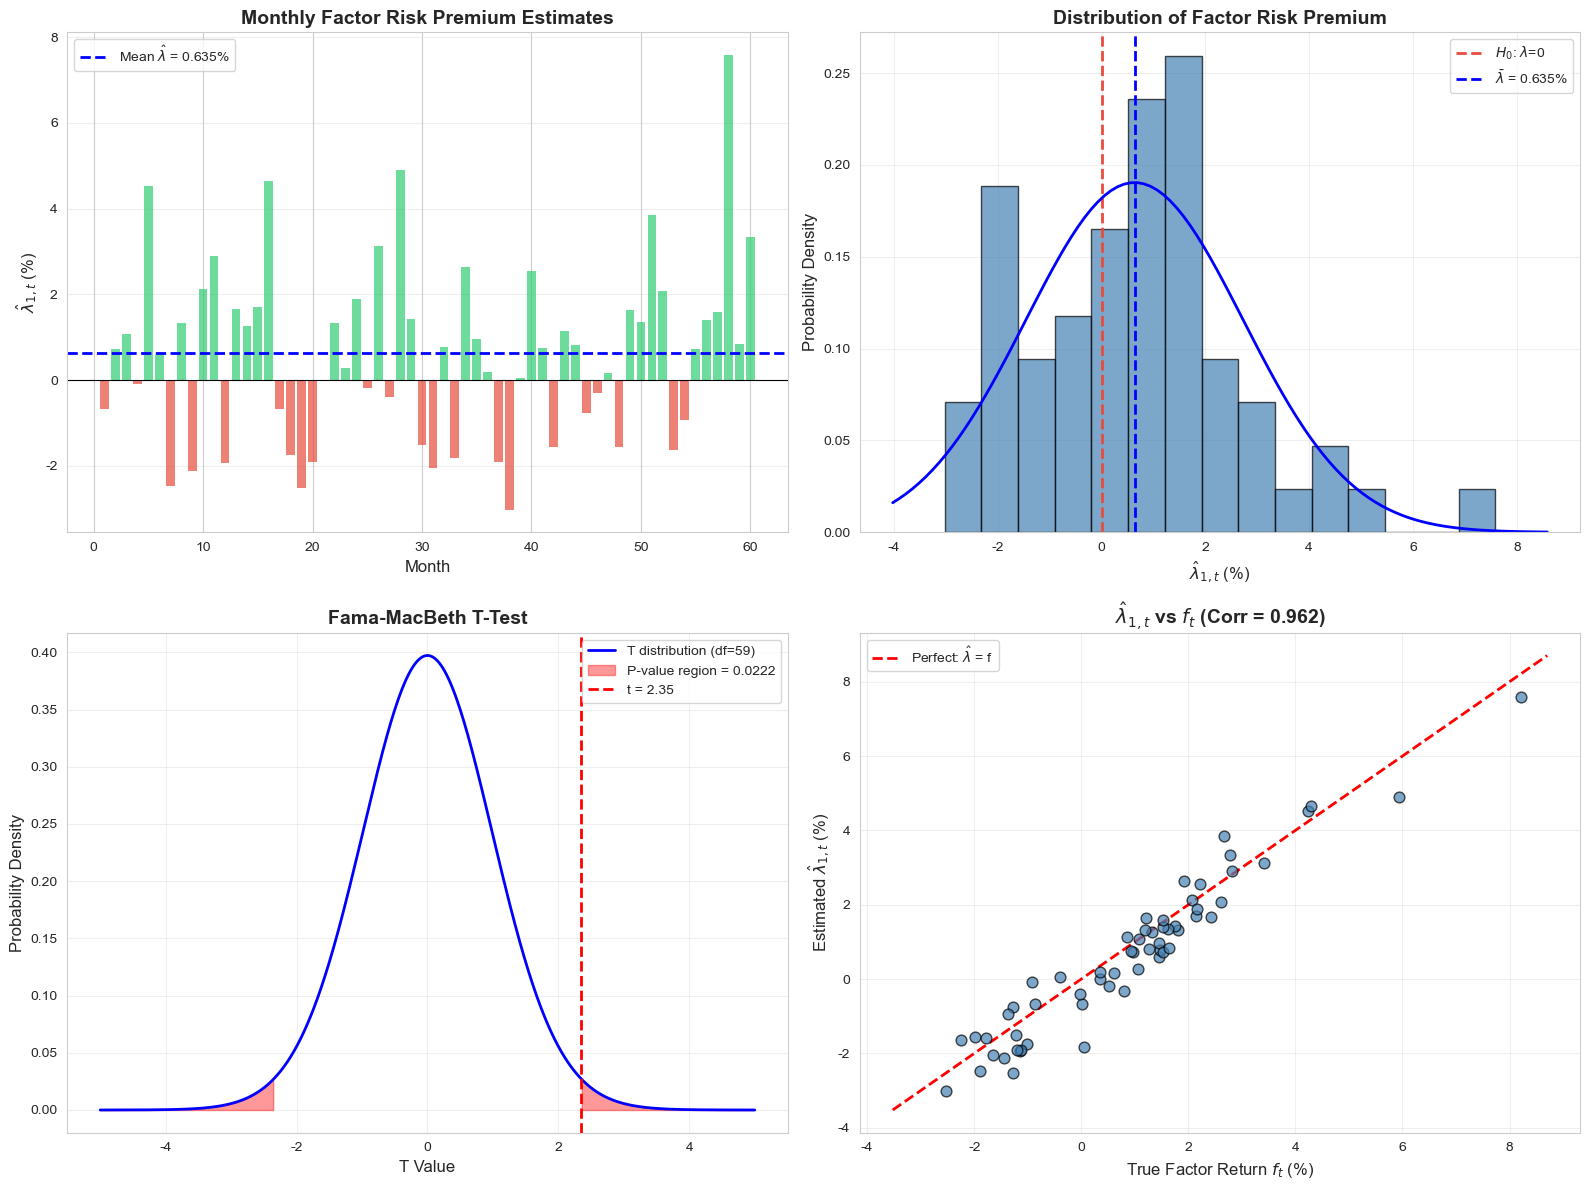


💡 图解说明：
  图1：每月的因子风险溢价估计 λ̂_1,t，绿=正/红=负
       蓝色虚线 = 时间序列均值 = 0.635%
  图2：λ̂ 的分布，蓝色虚线（均值）远离红色虚线（H₀: λ=0）
  图3：Fama-MacBeth t 检验，红色区域 = P 值 = 0.0222
  图4：估计的 λ̂_t 与真实因子收益 f_t 高度相关 (ρ=0.962)


In [ ]:
# ========== 可视化：Fama-MacBeth 回归结果 ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 图1: λ 时间序列 ---
ax1 = axes[0, 0]
months = range(1, N_MONTHS + 1)
ax1.bar(months, lambda_1_series,
        color=['#2ecc71' if v > 0 else '#e74c3c' for v in lambda_1_series],
        alpha=0.7, edgecolor='none')
ax1.axhline(y=lambda_mean, color='blue', linestyle='--', linewidth=2,
            label=f'Mean $\\hat{{\\lambda}}$ = {lambda_mean:.3f}%')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('$\\hat{\\lambda}_{1,t}$ (%)', fontsize=12)
ax1.set_title('Monthly Factor Risk Premium Estimates', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# --- 图2: λ 分布 ---
ax2 = axes[0, 1]
ax2.hist(lambda_1_series, bins=15, edgecolor='black', alpha=0.7,
         color='steelblue', density=True)
ax2.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=2, label='$H_0$: $\\lambda$=0')
ax2.axvline(x=lambda_mean, color='blue', linestyle='--', linewidth=2,
            label=f'$\\bar{{\\lambda}}$ = {lambda_mean:.3f}%')
# 正态拟合
x_fit = np.linspace(lambda_1_series.min() - 1, lambda_1_series.max() + 1, 100)
ax2.plot(x_fit, stats.norm.pdf(x_fit, lambda_mean, lambda_std), 'b-', linewidth=2)
ax2.set_xlabel('$\\hat{\\lambda}_{1,t}$ (%)', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title('Distribution of Factor Risk Premium', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# --- 图3: t 分布与 t 值 ---
ax3 = axes[1, 0]
x_t = np.linspace(-5, 5, 1000)
t_dist = stats.t.pdf(x_t, df=df_fm)
ax3.plot(x_t, t_dist, 'b-', linewidth=2, label=f'T distribution (df={df_fm})')
ax3.fill_between(x_t, t_dist, where=(x_t >= abs(t_fm)), color='red', alpha=0.4)
ax3.fill_between(x_t, t_dist, where=(x_t <= -abs(t_fm)), color='red', alpha=0.4,
                 label=f'P-value region = {p_fm:.4f}')
ax3.axvline(x=t_fm, color='red', linestyle='--', linewidth=2, label=f't = {t_fm:.2f}')
ax3.set_xlabel('T Value', fontsize=12)
ax3.set_ylabel('Probability Density', fontsize=12)
ax3.set_title('Fama-MacBeth T-Test', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# --- 图4: λ̂_t vs 真实 f_t ---
ax4 = axes[1, 1]
ax4.scatter(factor_rets, lambda_1_series, c='steelblue', s=60, edgecolors='black',
            alpha=0.7, zorder=5)
# 45度线
lims = [min(factor_rets.min(), lambda_1_series.min()) - 0.5,
        max(factor_rets.max(), lambda_1_series.max()) + 0.5]
ax4.plot(lims, lims, 'r--', linewidth=2, label='Perfect: $\\hat{\\lambda}$ = f')
corr_lf = np.corrcoef(factor_rets, lambda_1_series)[0, 1]
ax4.set_xlabel('True Factor Return $f_t$ (%)', fontsize=12)
ax4.set_ylabel('Estimated $\\hat{\\lambda}_{1,t}$ (%)', fontsize=12)
ax4.set_title(f'$\\hat{{\\lambda}}_{{1,t}}$ vs $f_t$ (Corr = {corr_lf:.3f})', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 图解说明：")
print(f"  图1：每月的因子风险溢价估计 λ̂_1,t，绿=正/红=负")
print(f"       蓝色虚线 = 时间序列均值 = {lambda_mean:.3f}%")
print(f"  图2：λ̂ 的分布，蓝色虚线（均值）远离红色虚线（H₀: λ=0）")
print(f"  图3：Fama-MacBeth t 检验，红色区域 = P 值 = {p_fm:.4f}")
print(f"  图4：估计的 λ̂_t 与真实因子收益 f_t 高度相关 (ρ={corr_lf:.3f})")

In [ ]:
# ========== Fama-MacBeth 完整汇总报告 ==========
# 95% 置信区间
t_critical = stats.t.ppf(0.975, df=df_fm)
margin = t_critical * lambda_se
ci_lower = lambda_mean - margin
ci_upper = lambda_mean + margin

print("=" * 60)
print("📋 Fama-MacBeth 回归完整报告")
print("=" * 60)
print(f"\n🎯 研究问题:")
print(f"   因子风险溢价是否显著不为零？")
print(f"\n📊 数据概况:")
print(f"   股票数量: {N_STOCKS} 只")
print(f"   时间跨度: {N_MONTHS} 个月")
print(f"\n🧮 Pass 1 (时间序列回归):")
print(f"   β̂ 均值: {est_betas_full.mean():.4f} (真实: {true_betas_full.mean():.4f})")
print(f"   β̂ 与真实 β 相关系数: {beta_corr:.4f}")
print(f"   |t(α)| > 1.96 的股票: {n_sig_alpha}/{N_STOCKS} ({n_sig_alpha/N_STOCKS*100:.1f}%)")
print(f"\n🧮 Pass 2 (截面回归):")
print(f"   因子溢价均值 λ̄: {lambda_mean:.4f}% /月")
print(f"   因子溢价年化:   {lambda_mean * 12:.4f}% /年")
print(f"   λ̂ 标准差:      {lambda_std:.4f}%")
print(f"   标准误 SE:      {lambda_se:.4f}%")
print(f"\n🧮 统计推断:")
print(f"   t 统计量: {t_fm:.4f}")
print(f"   P 值:     {p_fm:.6f}")
print(f"   95% CI:   [{ci_lower:.4f}%, {ci_upper:.4f}%]")
print(f"\n🎯 结论:")
if p_fm < 0.05:
    print(f"  ✓ 因子风险溢价显著不为零 (t={t_fm:.2f}, P={p_fm:.4f})")
    print(f"  ✓ 承担单位因子风险，月均补偿约 {lambda_mean:.3f}%")
else:
    print(f"  ✗ 因子风险溢价不显著 (t={t_fm:.2f}, P={p_fm:.4f})")
print(f"\n  💡 对比: 因子真实月均收益 = {factor_rets.mean():.4f}%")
print(f"          FM 估计 = {lambda_mean:.4f}% (误差 = {abs(lambda_mean - factor_rets.mean()):.4f}%)")
print("\n" + "=" * 60)

📋 Fama-MacBeth 回归完整报告

🎯 研究问题:
   因子风险溢价是否显著不为零？

📊 数据概况:
   股票数量: 200 只
   时间跨度: 60 个月

🧮 Pass 1 (时间序列回归):
   β̂ 均值: 0.9893 (真实: 0.9840)
   β̂ 与真实 β 相关系数: 0.8465
   |t(α)| > 1.96 的股票: 9/200 (4.5%)

🧮 Pass 2 (截面回归):
   因子溢价均值 λ̄: 0.6353% /月
   因子溢价年化:   7.6234% /年
   λ̂ 标准差:      2.0950%
   标准误 SE:      0.2705%

🧮 统计推断:
   t 统计量: 2.3489
   P 值:     0.022198
   95% CI:   [0.0941%, 1.1765%]

🎯 结论:
  ✓ 因子风险溢价显著不为零 (t=2.35, P=0.0222)
  ✓ 承担单位因子风险，月均补偿约 0.635%

  💡 对比: 因子真实月均收益 = 0.8814%
          FM 估计 = 0.6353% (误差 = 0.2461%)



---

## 5. Newey-West 标准误调整

### 📐 为什么 OLS 标准误会偏小？

在前面的 Fama-MacBeth 回归中，我们用 OLS 估计 $\lambda_t$，然后对 $\{\hat{\lambda}_t\}$ 的时间序列计算标准误。这里有一个关键假设：**残差 $\varepsilon_t$ 是独立同分布的 (i.i.d.)**。

但在金融数据中，这个假设往往不成立：

| 违反假设 | 金融数据的现实 | 后果 |
|---------|--------------|------|
| **自相关 (Autocorrelation)** | 收益率的波动具有聚集性（volatility clustering），残差往往正自相关 | OLS SE 偏小 |
| **异方差 (Heteroscedasticity)** | 不同时期的波动率不同（如牛市 vs 熊市） | OLS SE 偏小 |

当残差存在自相关和异方差时：

$$\text{OLS 标准误} \leq \text{真实标准误}$$

这意味着 **t 统计量被高估** → **p 值被低估** → **虚假拒绝原假设的概率增加**（第一类错误膨胀）。

**Newey-West (1987) 估计器**通过修正协方差矩阵来解决这个问题，它给出了在异方差和自相关一致 (HAC, Heteroscedasticity and Autocorrelation Consistent) 的标准误。

### 📐 Newey-West 公式

Newey-West 估计器的核心思想是用一个**核函数 (kernel function)** 对残差的自协方差进行加权求和：

$$\hat{V}_{NW} = \frac{1}{T} (X'X)^{-1} \hat{Q} (X'X)^{-1}$$

其中 $\hat{Q}$ 是修正后的「三明治」中间矩阵：

$$\hat{Q} = \hat{S}_0 + \sum_{j=1}^{J} w_j \left( \hat{S}_j + \hat{S}_j' \right)$$

各项定义如下：

$$\hat{S}_0 = \frac{1}{T} \sum_{t=1}^{T} \hat{\varepsilon}_t^2 \, x_t x_t'$$

$$\hat{S}_j = \frac{1}{T} \sum_{t=j+1}^{T} \hat{\varepsilon}_t \hat{\varepsilon}_{t-j} \, x_t x_{t-j}'$$

$$w_j = 1 - \frac{j}{J+1} \quad \text{（Bartlett 核权重）}$$

**带宽选择 (Bandwidth)**：

$$J = \lfloor T^{1/3} \rfloor$$

直觉理解：
- $\hat{S}_0$ 就是 White 异方差一致估计量（仅修正异方差）
- $\hat{S}_j$ 项捕获 $j$ 阶自相关的影响
- Bartlett 权重 $w_j$ 随滞后阶数 $j$ 线性衰减，保证 $\hat{Q}$ 是半正定的
- $J$ 越大，考虑的自相关阶数越多，但估计也越不稳定

### 🎯 微型例子：手算 Newey-West

我们用一个极小的例子来手算 Newey-West 标准误，然后用代码验证。

**设定**：
- 生成 $T = 30$ 期的 FM 回归残差，残差服从 AR(1) 过程：$\varepsilon_t = 0.6 \, \varepsilon_{t-1} + u_t$
- 只有截距项（单变量回归），所以 $x_t = 1$
- 带宽 $J = \lfloor 30^{1/3} \rfloor = \lfloor 3.107 \rfloor = 3$

In [ ]:
# ========== 微型例子：手算 Newey-West 标准误 ==========
np.random.seed(42)

T = 30  # 样本量
rho = 0.6  # AR(1) 系数

# 生成 AR(1) 残差
u = np.random.normal(0, 1, T)
eps = np.zeros(T)
eps[0] = u[0]
for t in range(1, T):
    eps[t] = rho * eps[t-1] + u[t]

# 单变量回归：x_t = 1（只有截距）
x = np.ones(T)

# 带宽
J = int(T ** (1/3))
print(f"样本量 T = {T}")
print(f"带宽 J = floor({T}^(1/3)) = {J}")
print(f"残差的 AR(1) 系数 ρ = {rho}")
print(f"残差一阶自相关: {np.corrcoef(eps[:-1], eps[1:])[0,1]:.4f}")

In [ ]:
# ========== 手算 Newey-West 各项 ==========

# Step 1: 计算 S_0 = (1/T) Σ ε²ₜ xₜxₜ'
S0 = (1/T) * np.sum(eps**2 * x**2)
print(f"S_0 = (1/T) Σ ε²ₜ · xₜ² = {S0:.6f}")
print(f"  → 这就是 White 异方差一致方差估计量")

# Step 2: 计算 S_j 和 Q
Q_hat = S0
print(f"\nQ = S_0 = {S0:.6f}")

for j in range(1, J + 1):
    # S_j = (1/T) Σ_{t=j+1}^{T} εₜ · εₜ₋ⱼ · xₜ · xₜ₋ⱼ
    Sj = (1/T) * np.sum(eps[j:] * eps[:-j] * x[j:] * x[:-j])
    # Bartlett 权重
    wj = 1 - j / (J + 1)
    # Q += w_j * (S_j + S_j')  —— 这里 x 是标量，S_j' = S_j
    contribution = wj * 2 * Sj
    Q_hat += contribution
    print(f"  S_{j} = {Sj:.6f},  w_{j} = {wj:.4f},  w_{j}·(S_{j}+S_{j}') = {contribution:.6f}")

print(f"\nQ_hat = {Q_hat:.6f}")

# Step 3: NW 方差 = (X'X)^{-1} · Q · (X'X)^{-1}
XtX_inv = 1 / (x @ x)  # (X'X)^{-1} 是标量
V_NW = XtX_inv * Q_hat * XtX_inv
SE_NW = np.sqrt(V_NW)

# 对比：OLS 方差（假设 iid）
V_OLS = (1/T) * S0 * XtX_inv * XtX_inv  # 简化的 OLS 方差
SE_OLS = np.sqrt(S0 / (x @ x))  # 等价于 sqrt(σ̂² / (X'X))

print(f"\n========== 结果对比 ==========")
print(f"OLS 标准误（假设 iid）: {SE_OLS:.6f}")
print(f"NW  标准误（HAC 修正）: {SE_NW:.6f}")
print(f"NW / OLS 比值:         {SE_NW / SE_OLS:.4f}")
if SE_NW > SE_OLS:
    print("\n结论: NW 标准误 > OLS 标准误，因为残差存在正自相关")
else:
    print("\n结论: NW 标准误 ≤ OLS 标准误，残差自相关不严重")

### 🔬 statsmodels 验证

上面是手算的 Newey-West 标准误。现在我们用 `statsmodels` 内置的 HAC 估计器来验证。

In [ ]:
# ========== 用 statsmodels 验证 Newey-West ==========

# 构造回归：y = β₀ + εₜ，其中 εₜ 是 AR(1)
y = eps.copy()  # 真实 β₀ = 0
X_reg = sm.add_constant(x)  # [1, 1, ..., 1]

# OLS 回归
model_ols = sm.OLS(y, X_reg).fit()
print("===== OLS 结果（默认标准误）=====")
print(f"截距估计: {model_ols.params[0]:.6f}")
print(f"OLS 标准误: {model_ols.bse[0]:.6f}")
print(f"OLS t 统计量: {model_ols.tvalues[0]:.4f}")

# Newey-West HAC 标准误
# maxlags = J = floor(T^{1/3})
model_hac = model_ols.get_robustcov_results(cov_type='HAC', maxlags=J, use_correction=True)
print(f"\n===== Newey-West HAC 结果 =====")
print(f"截距估计: {model_hac.params[0]:.6f}")
print(f"NW 标准误: {model_hac.bse[0]:.6f}")
print(f"NW t 统计量: {model_hac.tvalues[0]:.4f}")

# 与手算对比
print(f"\n===== 手算 vs statsmodels 对比 =====")
print(f"手算 OLS SE: {SE_OLS:.6f}  |  statsmodels OLS SE: {model_ols.bse[0]:.6f}")
print(f"手算 NW  SE: {SE_NW:.6f}  |  statsmodels NW  SE: {model_hac.bse[0]:.6f}")

In [ ]:
# ========== Fama-MacBeth 回归中的 Newey-West 修正 ==========
np.random.seed(42)

# 生成带有自相关残差的 FM 数据
N_STOCKS_FM = 100
T_FM = 120  # 10年月度数据

# 因子收益率
factor_returns = np.random.normal(0.005, 0.04, T_FM)

# 股票的真实 β
true_betas = np.random.uniform(0.5, 2.0, N_STOCKS_FM)

# 生成带自相关残差的股票收益
rho_resid = 0.5  # 残差自相关系数
panel_returns = np.zeros((N_STOCKS_FM, T_FM))
for i in range(N_STOCKS_FM):
    u = np.random.normal(0, 0.03, T_FM)
    eps_ar = np.zeros(T_FM)
    eps_ar[0] = u[0]
    for t in range(1, T_FM):
        eps_ar[t] = rho_resid * eps_ar[t-1] + u[t]
    panel_returns[i, :] = true_betas[i] * factor_returns + eps_ar

# Pass 1: 时间序列回归 → 估计 β
est_betas_fm = np.zeros(N_STOCKS_FM)
for i in range(N_STOCKS_FM):
    X_ts = sm.add_constant(factor_returns)
    model_ts = sm.OLS(panel_returns[i, :], X_ts).fit()
    est_betas_fm[i] = model_ts.params[1]

# Pass 2: 逐期截面回归 → 估计 λ_t
lambda_t_ols = np.zeros(T_FM)
for t in range(T_FM):
    X_cs = sm.add_constant(est_betas_fm)
    model_cs = sm.OLS(panel_returns[:, t], X_cs).fit()
    lambda_t_ols[t] = model_cs.params[1]

# ===== 方法 1: 传统 OLS 标准误 =====
lambda_mean = np.mean(lambda_t_ols)
SE_ols_fm = np.std(lambda_t_ols, ddof=1) / np.sqrt(T_FM)
t_ols_fm = lambda_mean / SE_ols_fm

# ===== 方法 2: Newey-West 标准误 =====
J_fm = int(T_FM ** (1/3))

# 对 λ_t 序列做截距回归，用 HAC 标准误
X_hac = sm.add_constant(np.ones(T_FM))
model_hac_fm = sm.OLS(lambda_t_ols, X_hac).fit()
model_hac_fm = model_hac_fm.get_robustcov_results(cov_type='HAC', maxlags=J_fm, use_correction=True)
SE_nw_fm = model_hac_fm.bse[0]
t_nw_fm = lambda_mean / SE_nw_fm

print(f"===== Fama-MacBeth: OLS vs Newey-West =====")
print(f"λ 均值:           {lambda_mean:.6f}")
print(f"OLS 标准误:       {SE_ols_fm:.6f}")
print(f"NW  标准误:       {SE_nw_fm:.6f}")
print(f"NW / OLS 比值:    {SE_nw_fm / SE_ols_fm:.4f}")
print(f"OLS t 统计量:     {t_ols_fm:.4f}")
print(f"NW  t 统计量:     {t_nw_fm:.4f}")
print(f"\n带宽 J = {J_fm}")
print(f"残差自相关系数 ρ = {rho_resid}")

In [ ]:
# ========== 可视化：OLS SE vs Newey-West SE ==========
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：标准误对比柱状图
ax1 = axes[0]
methods = ['OLS\n(假设iid)', 'Newey-West\n(HAC修正)']
ses = [SE_ols_fm, SE_nw_fm]
colors = ['#3498db', '#e74c3c']
bars = ax1.bar(methods, ses, color=colors, width=0.5, edgecolor='black')
ax1.set_ylabel('标准误', fontsize=12)
ax1.set_title('Fama-MacBeth λ 的标准误对比', fontsize=14)
for bar, se in zip(bars, ses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{se:.5f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(0, max(ses) * 1.3)

# 右图：λ_t 时间序列
ax2 = axes[1]
ax2.plot(range(T_FM), lambda_t_ols, color='#3498db', alpha=0.7, linewidth=0.8)
ax2.axhline(y=lambda_mean, color='red', linestyle='--', label=f'λ 均值 = {lambda_mean:.4f}')
ax2.axhline(y=lambda_mean + 1.96*SE_ols_fm, color='#3498db', linestyle=':', alpha=0.7,
             label=f'OLS 95% CI (±{1.96*SE_ols_fm:.4f})')
ax2.axhline(y=lambda_mean - 1.96*SE_ols_fm, color='#3498db', linestyle=':', alpha=0.7)
ax2.axhline(y=lambda_mean + 1.96*SE_nw_fm, color='#e74c3c', linestyle=':', alpha=0.7,
             label=f'NW 95% CI (±{1.96*SE_nw_fm:.4f})')
ax2.axhline(y=lambda_mean - 1.96*SE_nw_fm, color='#e74c3c', linestyle=':', alpha=0.7)
ax2.set_xlabel('时期 t', fontsize=12)
ax2.set_ylabel('$\\lambda_t$', fontsize=14)
ax2.set_title('逐期截面回归 $\\lambda_t$ 及置信区间', fontsize=14)
ax2.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.show()

print(f"\n===== 解读 =====")
print(f"NW 标准误 ({SE_nw_fm:.5f}) > OLS 标准误 ({SE_ols_fm:.5f})")
print(f"比值: {SE_nw_fm/SE_ols_fm:.2f}x")
print(f"\n使用 OLS 标准误会高估 t 统计量，增加虚假显著的风险")
print(f"使用 NW 标准误给出更保守、更可靠的推断")

### 💡 关键直觉

1. **$\text{SE}_{NW} \geq \text{SE}_{OLS}$（总是成立）**：Newey-West 只会增加（或保持不变）标准误，永远不会减小。

2. **自相关越强，差异越大**：当残差的 AR(1) 系数 $\rho$ 接近 1 时，NW 标准误会远大于 OLS 标准误。当 $\rho \approx 0$ 时，两者几乎相等。

3. **带宽 $J$ 的选择影响估计**：$J$ 太小会遗漏高阶自相关，$J$ 太大会引入过多噪声。$J = \lfloor T^{1/3} \rfloor$ 是理论最优的折中。

4. **实践建议**：在 Fama-MacBeth 回归中，**始终使用 Newey-West 标准误**做推断，因为金融数据几乎总有一定程度的自相关和异方差。

$$\boxed{\text{在金融实证中，Newey-West 标准误是 Fama-MacBeth 推断的标准做法}}$$

---

## 6. 拓展：当 α 不为零时

### 🎯 对比实验

前面的 DGP 设定 $\alpha = 0$（模型正确）。现在我们看看如果部分股票有 $\alpha \neq 0$ 会怎样。

设定：前 20 只股票有正的 $\alpha$（月均 1%），其余股票 $\alpha = 0$。

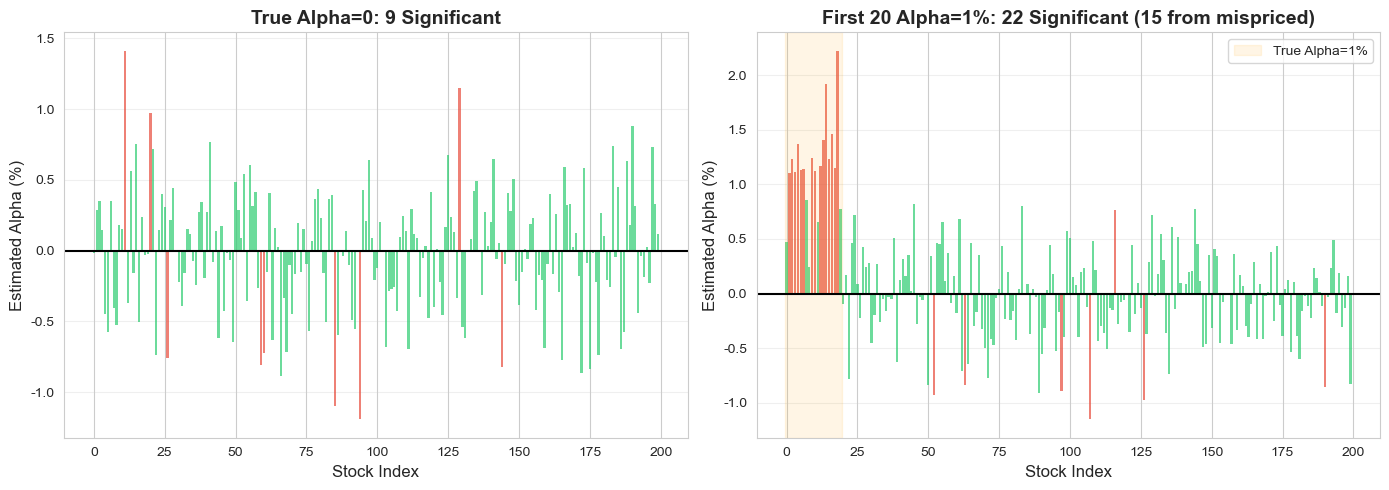


💡 对比分析：
  左图（α=0）：只有 9 只股票的 α 显著（假阳性，预期 ~10）
  右图（前20只 α=1%）：共 22 只显著，其中 15 只来自真正有异常收益的股票
  时间序列回归能有效识别出定价误差！


In [ ]:
# ========== 对比实验：α ≠ 0 ==========
np.random.seed(42)

# 新的 α：前 20 只股票有正 α
true_alphas_mis = np.zeros(N_STOCKS)
true_alphas_mis[:20] = 1.0  # 月均 1% 的异常收益

# 重新生成收益
panel_returns_mis = np.zeros((N_STOCKS, N_MONTHS))
for i in range(N_STOCKS):
    eps = np.random.normal(0, sigma_eps, N_MONTHS)
    panel_returns_mis[i, :] = true_alphas_mis[i] + true_betas_full[i] * factor_rets + eps

# Pass 1: 时间序列回归
est_alphas_mis = np.zeros(N_STOCKS)
est_betas_mis = np.zeros(N_STOCKS)
t_alphas_mis = np.zeros(N_STOCKS)
p_alphas_mis = np.zeros(N_STOCKS)

X_ts = sm.add_constant(factor_rets)
for i in range(N_STOCKS):
    model_i = sm.OLS(panel_returns_mis[i, :], X_ts).fit()
    est_alphas_mis[i] = model_i.params[0]
    est_betas_mis[i] = model_i.params[1]
    t_alphas_mis[i] = model_i.tvalues[0]
    p_alphas_mis[i] = model_i.pvalues[0]

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左图：α=0 的情况 ---
ax1 = axes[0]
colors1 = ['#e74c3c' if abs(t) > 1.96 else '#2ecc71' for t in t_alphas_full]
ax1.bar(range(N_STOCKS), est_alphas_full, color=colors1, alpha=0.7, edgecolor='none')
ax1.axhline(y=0, color='black', linewidth=1.5)
ax1.set_xlabel('Stock Index', fontsize=12)
ax1.set_ylabel('Estimated Alpha (%)', fontsize=12)
n_sig1 = sum(abs(t) > 1.96 for t in t_alphas_full)
ax1.set_title(f'True Alpha=0: {n_sig1} Significant', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# --- 右图：前20只 α=1 的情况 ---
ax2 = axes[1]
colors2 = ['#e74c3c' if abs(t) > 1.96 else '#2ecc71' for t in t_alphas_mis]
ax2.bar(range(N_STOCKS), est_alphas_mis, color=colors2, alpha=0.7, edgecolor='none')
ax2.axhline(y=0, color='black', linewidth=1.5)
# 标注有正 α 的区域
ax2.axvspan(-0.5, 19.5, alpha=0.1, color='orange', label='True Alpha=1%')
ax2.set_xlabel('Stock Index', fontsize=12)
ax2.set_ylabel('Estimated Alpha (%)', fontsize=12)
n_sig2 = sum(abs(t) > 1.96 for t in t_alphas_mis)
n_sig_first20 = sum(abs(t_alphas_mis[i]) > 1.96 for i in range(20))
ax2.set_title(f'First 20 Alpha=1%: {n_sig2} Significant ({n_sig_first20} from mispriced)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 对比分析：")
print(f"  左图（α=0）：只有 {n_sig1} 只股票的 α 显著（假阳性，预期 ~{N_STOCKS*0.05:.0f}）")
print(f"  右图（前20只 α=1%）：共 {n_sig2} 只显著，其中 {n_sig_first20} 只来自真正有异常收益的股票")
print(f"  时间序列回归能有效识别出定价误差！")

---

## 7. 不同回归方法比较

### 📝 方法对比总结

| 特性 | 时间序列回归 | 截面回归 | Fama-MacBeth 回归 |
|------|------------|----------|------------------|
| **回归方向** | 时间维度（跨月份） | 截面维度（跨股票） | 两步法 |
| **第一步** | — | 需先得到 β̂ | 时间序列回归→β̂ |
| **回归方程** | $r_{i,t}=\alpha_i+\beta_i f_t+\varepsilon_{i,t}$ | $r_{i,t}=\lambda_{0,t}+\lambda_{1,t}\hat{\beta}_i+e_{i,t}$ | 同截面回归（逐期） |
| **主要估计量** | α（定价误差）, β（因子暴露） | λ（因子风险溢价） | λ̄（因子风险溢价均值） |
| **核心检验** | α = 0？（GRS 检验） | λ ≠ 0？ | λ̄ ≠ 0？（t 检验） |
| **回答的问题** | 因子模型是否正确？ | 因子溢价有多大？ | 因子溢价是否显著？ |
| **标准误** | OLS 标准误 | OLS 标准误（有 EIV 问题） | 时间序列标准差/√T（自然修正截面相关） |
| **优势** | 直接检验模型 | 直接估计经济量 | ✅ 修正截面相关性 |
| **劣势** | 无法估计溢价 | EIV 问题 | 仍有 EIV 问题 |
| **适用场景** | 检验因子模型有效性 | 单期分析 | ✅ 最常用的标准方法 |

### 📖 书中要点

> Fama-MacBeth 回归是学术研究中检验因子定价能力的标准方法。它的核心优势在于：(1) 通过对逐期 λ 取均值，自然解决了截面残差的相关性问题；(2) 可以方便地加入多个因子。但 EIV 问题仍然存在，Shanken (1992) 提出了修正方法。

### 💡 何时用哪种方法？

```
你想回答什么问题？
    |
    ├── "因子模型设定对不对？" → 时间序列回归 + GRS 检验
    |
    ├── "因子溢价有多大？" → Fama-MacBeth 回归（标准方法）
    |
    └── "因子暴露能否解释截面收益差异？" → Fama-MacBeth 回归
```

---

## 8. 核心概念回顾

### 📌 时间序列回归 (Time-Series Regression)
- **定义**: 对每只股票跨时间回归，估计因子暴露 β 和定价误差 α
- **公式**: $r_{i,t} - r_{f,t} = \alpha_i + \beta_i f_t + \varepsilon_{i,t}$
- **含义**: α = 0 说明因子模型完美解释超额收益
- **判断标准**: GRS 检验联合判断所有 α = 0

### 📌 截面回归 (Cross-Sectional Regression)
- **定义**: 在每个时期跨股票回归，估计因子风险溢价 λ
- **公式**: $r_{i,t} = \lambda_{0,t} + \lambda_{1,t} \hat{\beta}_i + e_{i,t}$
- **含义**: λ > 0 说明承担因子风险有正的补偿
- **判断标准**: λ 的 t 统计量是否显著

### 📌 Fama-MacBeth 回归 (Two-Pass Regression)
- **定义**: 两步法——先时间序列回归得 β，再逐期截面回归得 λ_t，最后对 λ_t 做 t 检验
- **公式**: $t_{FM} = \bar{\lambda} / (\sigma(\hat{\lambda}) / \sqrt{T})$
- **含义**: 同时估计因子溢价和检验显著性
- **判断标准**: |t| > 2（经验法则），P < 0.05

### 📌 定价误差 Alpha (α)
- **定义**: 因子模型无法解释的"额外"收益
- **公式**: $\alpha_i = \bar{r}_i - \hat{\beta}_i \bar{f}$
- **含义**: α > 0 说明实际收益高于模型预测
- **判断标准**: 联合检验 α = 0（GRS 检验）

### 📌 因子风险溢价 Lambda (λ)
- **定义**: 承担单位因子风险获得的期望补偿
- **公式**: 从截面回归或 Fama-MacBeth 回归的斜率估计
- **含义**: λ 对应因子的"价格"，β 对应因子的"数量"
- **判断标准**: λ 的 FM t 统计量 > 2

### 🔗 完整流程

```
数据准备 → Pass 1: 时间序列回归 → 得到 β̂ → Pass 2: 逐期截面回归 → 得到 λ̂_t 序列
    ↓                                                       ↓
  N 只股票                                          对 λ̂_t 取均值和标准差
  T 个月                                                    ↓
                                                   t = λ̄ / SE(λ̄)
                                                           ↓
                                                  判断因子溢价是否显著
```

### 📝 检验指标汇总

| 方法 | 估计量 | 核心检验 | 经验阈值 |
|------|--------|---------|----------|
| 时间序列回归 | α, β | H₀: α = 0 (GRS) | F 统计量的 P 值 |
| 截面回归 | λ | H₀: λ = 0 | \|t\| > 2 |
| Fama-MacBeth | λ̄ | H₀: λ̄ = 0 | \|t\| > 2, P < 0.05 |

---

## 9. 常见误区提醒

### ❌ 误区 1: 截面回归直接用 OLS 标准误做推断
**✓ 正确理解**: 单期截面回归的 OLS 标准误没有考虑 β 的估计误差 (EIV 问题)，也没有考虑不同时期残差的截面相关性。应该使用 Fama-MacBeth 方法（对 λ_t 的时间序列计算标准误），或使用 Shanken (1992) 修正。

### ❌ 误区 2: 认为时间序列回归和截面回归是替代关系
**✓ 正确理解**: 两种方法回答**不同的问题**。时间序列回归检验"模型对不对"（α=0?），截面回归检验"因子溢价多大"（λ>0?）。它们是**互补关系**。

### ❌ 误区 3: 在 Fama-MacBeth 中使用滚动窗口 β 但忽略前瞻偏差
**✓ 正确理解**: 如果用全样本时间序列回归估计 β（而非仅用 t 之前的数据），会引入前瞻偏差 (look-ahead bias)。严格的做法是用滚动窗口或递增窗口估计 β。

### ❌ 误区 4: 认为 α 显著不为零就一定是"免费午餐"
**✓ 正确理解**: α 只是相对于**当前因子模型**的定价误差。如果你换一个更好的因子模型（加入更多因子），α 可能变成零。所以 α 不等于"套利机会"，而是"模型不完整"的信号。

### ❌ 误区 5: 认为 Fama-MacBeth 回归完全解决了 EIV 问题
**✓ 正确理解**: Fama-MacBeth 方法解决了截面残差相关性的问题，但 EIV (Errors-in-Variables) 问题仍然存在——因为第二步截面回归的自变量 β̂ 是估计值而非真值，这会导致 λ 的估计有偏。Shanken (1992) 修正可以部分解决此问题。